In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, recall_score
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [5]:
diabetes_dataset = pd.read_csv("diabetes.csv")
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
diabetes_dataset.shape

(768, 9)

In [7]:
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
diabetes_dataset['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [10]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


Text(0, 0.5, 'count')

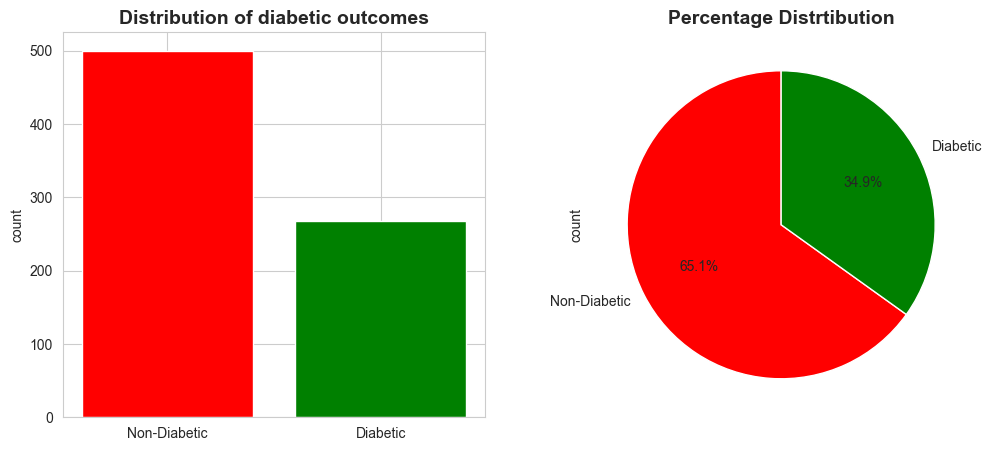

In [13]:
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
outcome_counts = diabetes_dataset['Outcome'].value_counts()
plt.bar(['Non-Diabetic', 'Diabetic'], outcome_counts.values, color=['red', 'green'])
plt.title('Distribution of diabetic outcomes', fontsize=14, fontweight='bold')
plt.ylabel('count')

plt.subplot(1,2,2)
plt.pie(outcome_counts.values, labels=['Non-Diabetic', 'Diabetic'], autopct='%1.1f%%', colors=['red', 'green'], startangle=90)
plt.title('Percentage Distrtibution', fontsize=14, fontweight='bold')
plt.ylabel('count')

<function matplotlib.pyplot.show(close=None, block=None)>

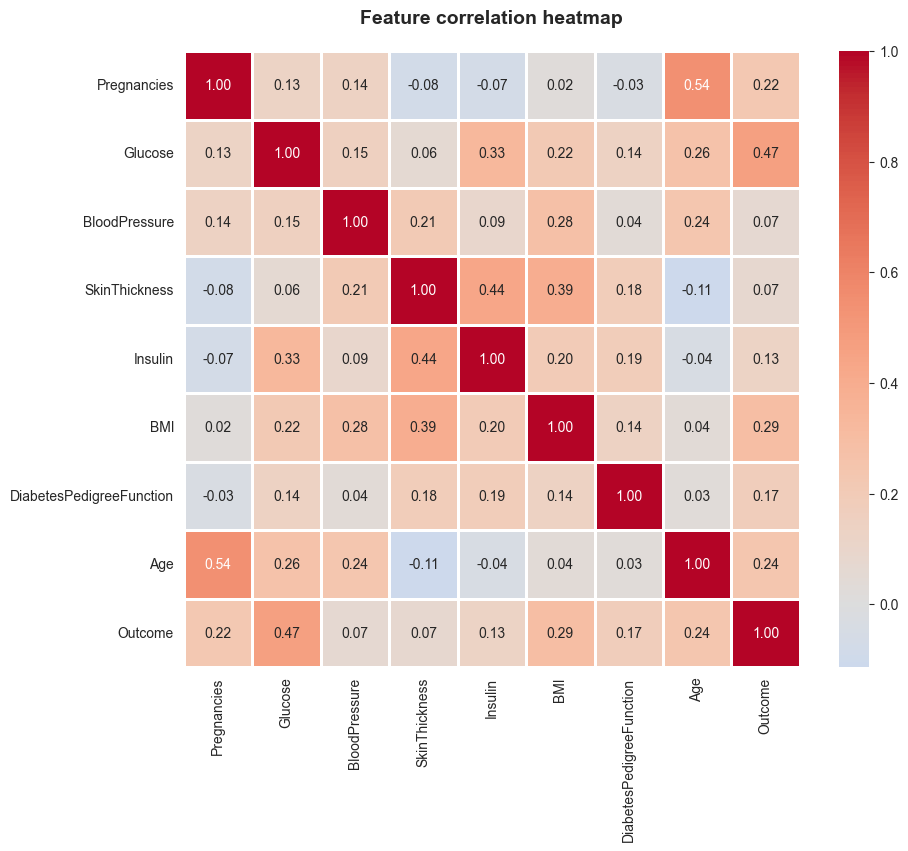

In [14]:
plt.figure(figsize=(10,8))
correlation = diabetes_dataset.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square=True, linewidth=1, fmt='.2f')
plt.title('Feature correlation heatmap', fontsize=14, pad=20, fontweight='bold')
plt.show

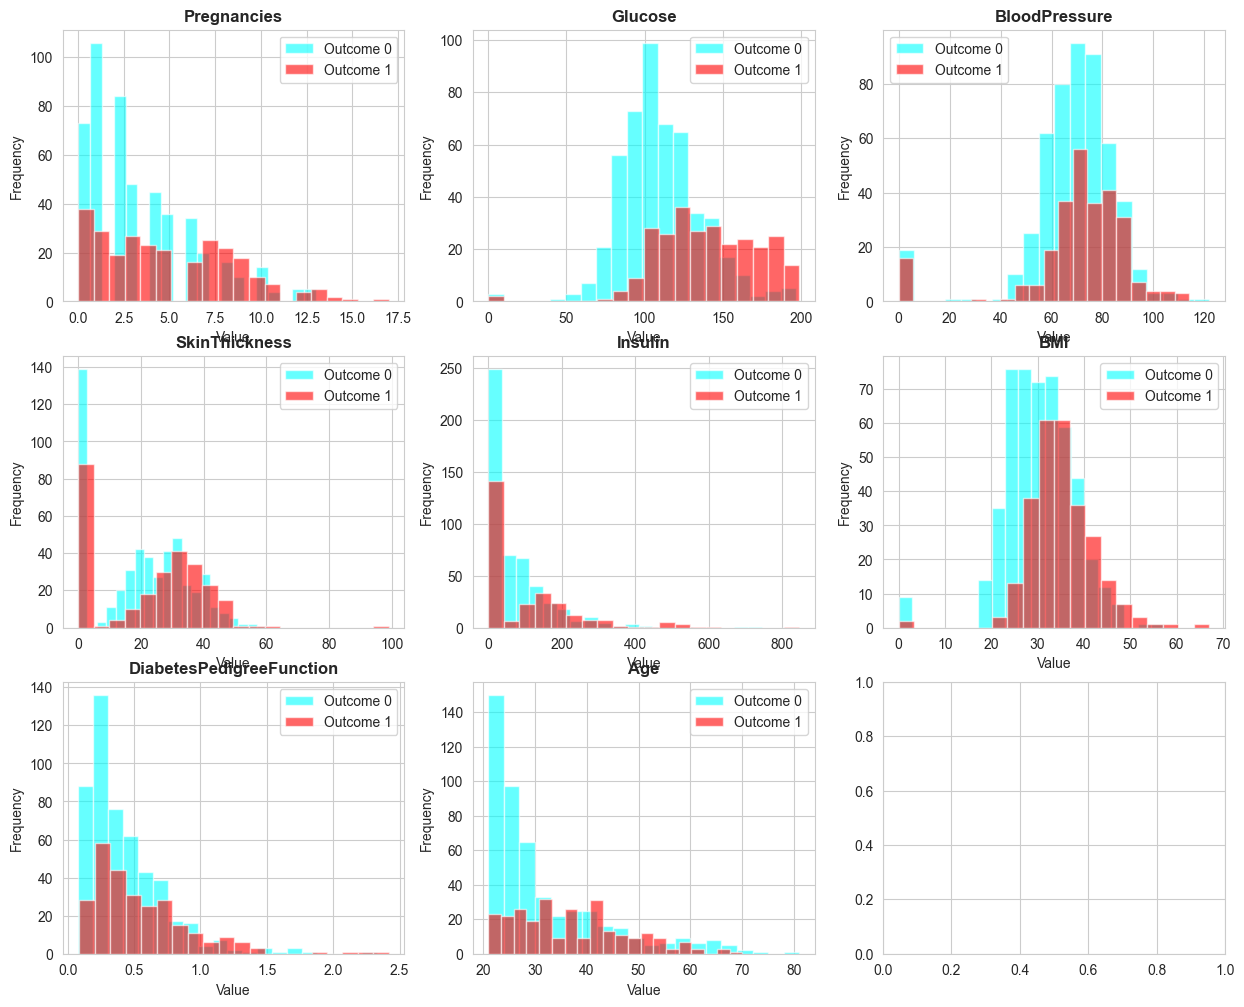

In [17]:
fig, axes = plt.subplots(3,3,figsize=(15,12))
features = diabetes_dataset.columns[:-1]

for idx, feature in enumerate(features):
    row, col = idx//3, idx % 3
    for outcome in [0,1]:
        data = diabetes_dataset[diabetes_dataset['Outcome'] == outcome][feature]
        axes[row,col].hist(data, alpha = 0.6, bins = 20, label=f'Outcome {outcome}', color =['cyan','red'][outcome])
        axes[row,col].set_title(feature, fontweight='bold')
        axes[row,col].set_xlabel('Value')
        axes[row,col].set_ylabel('Frequency')
        axes[row,col].legend()
plt.show()

In [18]:
x = diabetes_dataset.drop(columns='Outcome', axis=1)
y = diabetes_dataset['Outcome']

print(x)
print(y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [21]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify = y, random_state = 2)

print(x.shape, x_train.shape, x_test.shape)

(768, 8) (614, 8) (154, 8)


In [23]:
classifier = svm.SVC(kernel='linear', probability=True)
classifier.fit(x_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [24]:
x_train_prediction = classifier.predict(x_train)
training_data_accuracy = accuracy_score(x_train_prediction, y_train)
training_data_accuracy

0.7866449511400652

In [25]:
x_test_prediction = classifier.predict(x_test)
test_data_accuracy = accuracy_score(x_test_prediction, y_test)
test_data_accuracy

0.7727272727272727

In [27]:
precision = precision_score(y_test, x_test_prediction)
recall = recall_score(y_test, x_test_prediction)
f1 = f1_score(y_test, x_test_prediction)

print(precision, recall, f1)

0.7567567567567568 0.5185185185185185 0.6153846153846154


In [28]:
cm_svm = confusion_matrix(y_test, x_test_prediction)
cm_svm

array([[91,  9],
       [26, 28]])

Text(0.5, 36.72222222222221, 'Predicted')

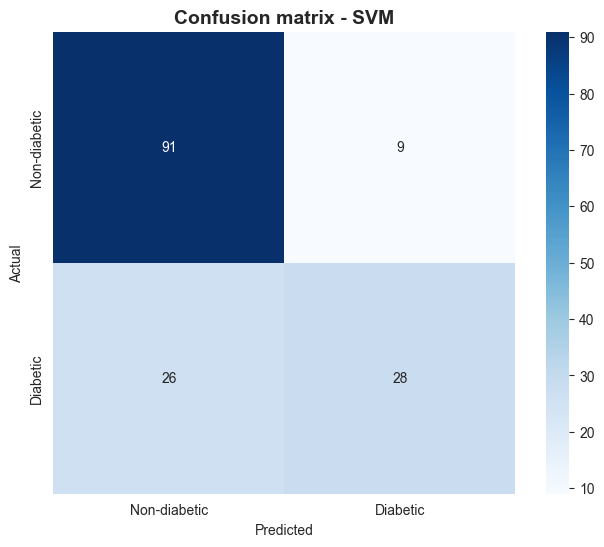

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', square=True,
           xticklabels=['Non-diabetic','Diabetic'],
           yticklabels=['Non-diabetic','Diabetic'])
plt.title('Confusion matrix - SVM', fontsize=14,fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

In [30]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=2)
rf_classifier.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
x_train_prediction_rf = rf_classifier.predict(x_train)

In [32]:
training_data_accuracy_rf = accuracy_score(x_train_prediction_rf, y_train)
training_data_accuracy_rf

1.0

In [34]:
x_test_prediction_rf = rf_classifier.predict(x_test)

In [35]:
test_data_accuracy_rf = accuracy_score(x_test_prediction_rf, y_test)
test_data_accuracy_rf

0.7272727272727273

In [36]:
precision = precision_score(y_test, x_test_prediction_rf)
recall = recall_score(y_test, x_test_prediction_rf)
f1 = f1_score(y_test, x_test_prediction_rf)

print(precision, recall, f1)

0.65 0.48148148148148145 0.5531914893617021


In [37]:
cm_rf = confusion_matrix(y_test, x_test_prediction_rf)
cm_rf

array([[86, 14],
       [28, 26]])

Text(0.5, 36.72222222222221, 'Predicted')

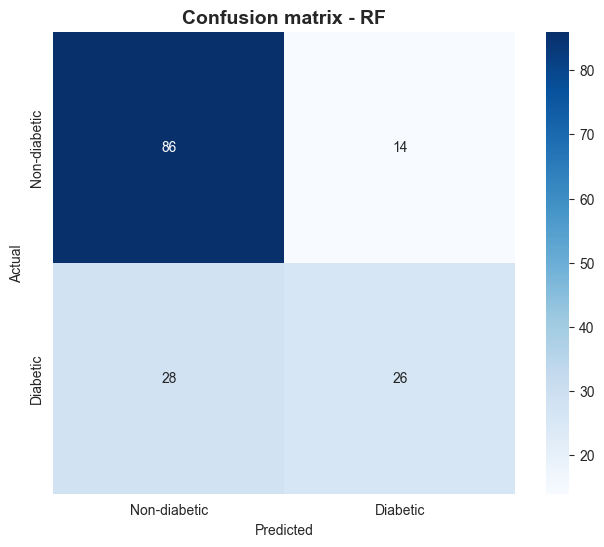

In [38]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', square=True,
           xticklabels=['Non-diabetic','Diabetic'],
           yticklabels=['Non-diabetic','Diabetic'])
plt.title('Confusion matrix - RF', fontsize=14,fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

In [39]:
print('SVM:', test_data_accuracy)
print('RF:', test_data_accuracy_rf)

SVM: 0.7727272727272727
RF: 0.7272727272727273


In [40]:
joblib.dump(classifier, 'diabetes_model.pkl')

['diabetes_model.pkl']